In [1]:
# Importar bibliotecas necessárias
import binascii
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

2026-01-15 16:29:02.879933: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-15 16:29:02.934934: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 16:29:04.335315: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Classificação de Dígitos MNIST com CNN

Este notebook implementa uma Rede Neural Convolucional (CNN) otimizada para classificação de dígitos manuscritos do dataset MNIST. O modelo é especialmente projetado para deployment em microcontroladores (Raspberry Pi Pico) usando TensorFlow Lite com quantização INT8.

## 1. Carregar e Pré-processar Dataset MNIST

Formato dos dados: (60000, 28, 28, 1), (60000,)
Faixa de valores: [0.00, 1.00]


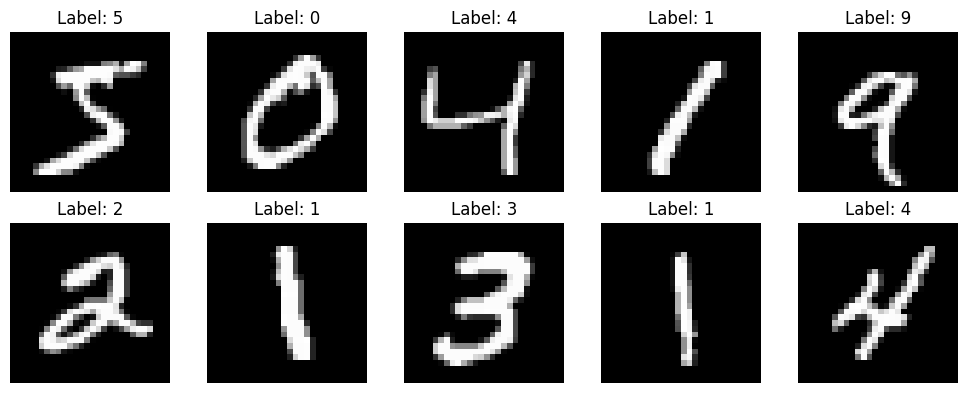

In [2]:
# Carregar dataset MNIST (60k treino + 10k teste)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Pré-processamento:
# - Reshape: adicionar dimensão de canal (28, 28, 1) para entrada convolucional
# - Normalização: converter de [0, 255] para [0.0, 1.0]
# - Forçar dtype float32 (requerido pelo TensorFlow)
x_train = x_train.reshape(-1, 28, 28, 1).astype(np.float32) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype(np.float32) / 255.0

print(f"Formato dos dados: {x_train.shape}, {y_train.shape}")
print(f"Faixa de valores: [{x_train.min():.2f}, {x_train.max():.2f}]")

# Visualizar primeiras 10 amostras do dataset
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Arquitetura do Modelo CNN

### Otimizações para TinyML:
- **~2K parâmetros**: Modelo compacto para microcontroladores (~8KB flash)
- **BatchNormalization**: Normalização sem parâmetros extras (usa_bias=False)
- **Stride ao invés de MaxPooling**: Reduz memória e operações
- **GlobalAveragePooling2D**: Substitui Flatten + Dense, reduzindo parâmetros

In [3]:
# Construir modelo CNN otimizado
model = tf.keras.Sequential([
    # Entrada: 28x28x1 (imagem grayscale)
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # Primeira camada convolucional: 8 filtros, kernel 3x3, stride 2
    tf.keras.layers.Conv2D(8, 3, strides=2, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    # Segunda camada convolucional: 16 filtros, kernel 3x3, stride 2
    tf.keras.layers.Conv2D(16, 3, strides=2, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    # Pooling global + regularização
    tf.keras.layers.GlobalAveragePooling2D(),

    # Camada de saída: 10 classes (dígitos 0-9)
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compilar modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Visualizar arquitetura e contagem de parâmetros
model.summary()

2026-01-15 16:29:06.219661: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 16)       │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,490 (5.82 KB)

 Trainable params: 1,442 (5.63 KB)

 Non-trainable params: 48 (192.00 B)

## 3. Treinar o Modelo

### Técnicas de Treinamento:
- **Data Augmentation**: Translação e rotação aleatórias para melhor generalização
- **Learning Rate Scheduling**: Reduz LR quando validação estagnar (ReduceLROnPlateau)
- **Validation Split**: 10% dos dados de treino para monitoramento

In [4]:
# Configurar callbacks para otimização de treinamento
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# Treinar modelo
history = model.fit(
    x_train,
    y_train,
    epochs=40,
    batch_size=128,
    validation_split=0.1,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/40


2026-01-15 16:29:06.400694: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 169344000 exceeds 10% of free system memory.


422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3093 - loss: 2.0230 - val_accuracy: 0.1495 - val_loss: 2.1868 - learning_rate: 0.0010
Epoch 2/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5023 - loss: 1.6144 - val_accuracy: 0.4620 - val_loss: 1.5192 - learning_rate: 0.0010
Epoch 3/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6028 - loss: 1.3259 - val_accuracy: 0.6353 - val_loss: 1.2035 - learning_rate: 0.0010
Epoch 4/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6574 - loss: 1.1498 - val_accuracy: 0.6525 - val_loss: 1.1029 - learning_rate: 0.0010
Epoch 5/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6981 - loss: 1.0277 - val_accuracy: 0.6953 - val_loss: 0.9821 - learning_rate: 0.0010
Epoch 6/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7290 - loss: 0.9359 - val_accuracy: 0.7473 - val_loss: 0.8756 - learning_rate: 0.0010
Epoch 7/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7530 - loss: 0.8632 - val_

## 4. Avaliar Desempenho do Treinamento

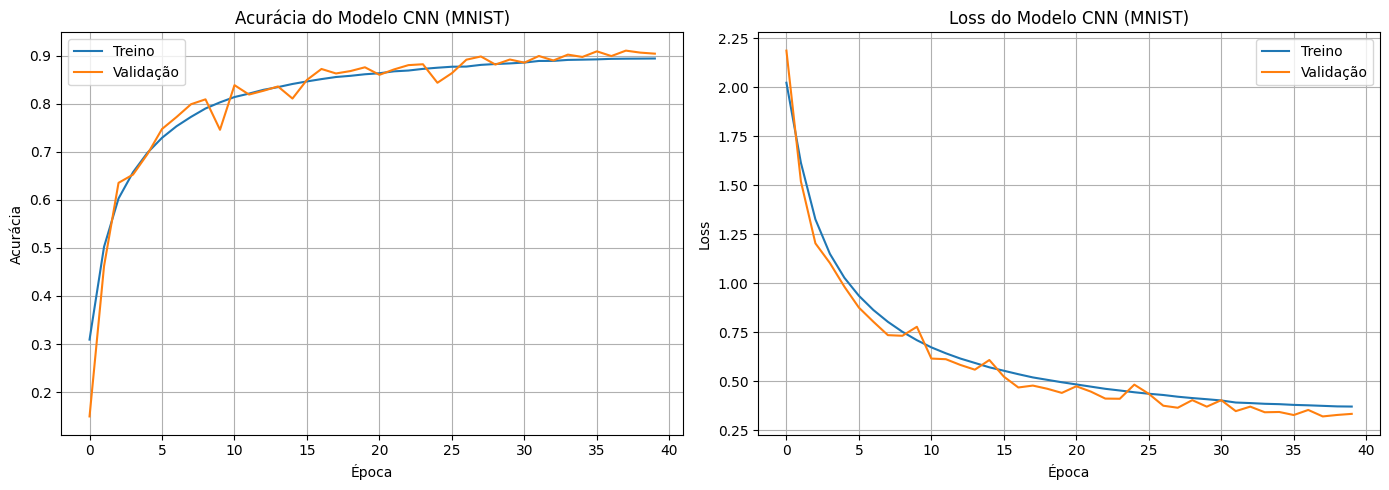

In [5]:
# Criar subplots lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === Acurácia ===
ax1.plot(history.history['accuracy'], label='Treino')
ax1.plot(history.history['val_accuracy'], label='Validação')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.set_title('Acurácia do Modelo CNN (MNIST)')
ax1.legend()
ax1.grid(True)

# === Loss ===
ax2.plot(history.history['loss'], label='Treino')
ax2.plot(history.history['val_loss'], label='Validação')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.set_title('Loss do Modelo CNN (MNIST)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 5. Avaliar Métricas de Classificação

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


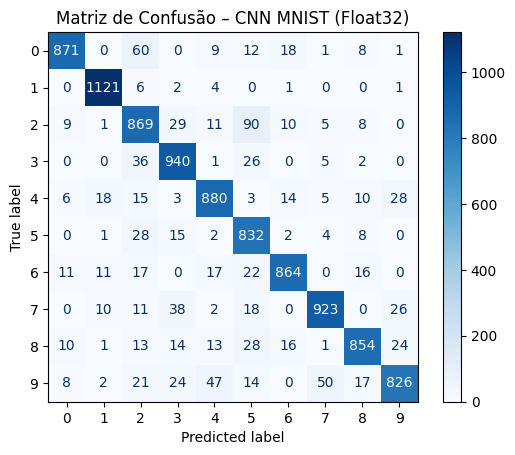


Acurácia final (treino):     89.39%
Acurácia final (validação):  90.40%


In [6]:
# Gerar predições no conjunto de teste
y_pred = np.argmax(model.predict(x_test), axis=1)

# Calcular e visualizar matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão – CNN MNIST (Float32)")
plt.show()

# Exibir acurácias finais
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n{'='*50}")
print(f"Acurácia final (treino):     {final_train_acc*100:.2f}%")
print(f"Acurácia final (validação):  {final_val_acc*100:.2f}%")
print(f"{'='*50}")

## 6. Salvar Modelo Float32

In [7]:
# Criar diretório de saída
if not os.path.exists("../models"):
    os.makedirs("../models")

# Salvar modelo em formato Keras
model.save("../models/mnist_cnn_float.keras")
print("✓ Modelo salvo: ../models/mnist_cnn_float.keras")

✓ Modelo salvo: ../models/mnist_cnn_float.keras


## 7. Conversão para TensorFlow Lite INT8

### Por que INT8?
- **Menor tamanho**: ~4x menor que float32
- **Execução mais rápida**: Operações inteiras são mais eficientes em MCUs
- **Menor consumo de memória**: Crítico para Raspberry Pi Pico (264KB RAM)

### Processo de Quantização:
1. **Representative Dataset**: Calibra escalas com dados reais
2. **INT8 Operations**: Todas as operações em inteiros de 8 bits
3. **INT8 I/O**: Entrada e saída também quantizadas

In [8]:
# Dataset representativo para calibração da quantização
def rep_data_gen():
    """
    Fornece amostras representativas para o conversor TFLite calibrar
    os parâmetros de quantização (scale e zero_point).
    Usa 200 amostras do conjunto de treino com o mesmo pré-processamento.
    IMPORTANTE: Retorna float32 explicitamente (TFLite não aceita float64).
    """
    for i in range(200):
        yield [x_train[i:i+1].astype(np.float32)]

# Configurar conversor TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_data_gen

# Forçar quantização completa para INT8 (ideal para microcontroladores)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Gerar modelo quantizado
tflite_int8 = converter.convert()

# Salvar modelo TFLite
output_path = "../models/mnist_cnn_int8.tflite"
with open(output_path, "wb") as f:
    f.write(tflite_int8)

print(f"✓ Modelo TFLite INT8 salvo: {output_path}")
print(f"✓ Tamanho: {len(tflite_int8):,} bytes (~{len(tflite_int8)/1024:.1f} KB)")

INFO:tensorflow:Assets written to: /tmp/tmptzgb8lys/assets


INFO:tensorflow:Assets written to: /tmp/tmptzgb8lys/assets


Saved artifact at '/tmp/tmptzgb8lys'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  125715203278416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715202908496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715202908304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715203280336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715203288592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715203397520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715203393488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715203397328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715202908688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715202908112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125715203399248

/home/matheus/Documentos/Meus Codes/Embarcatech/tarefa28_IA4_embarcatech/.venv/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1768505529.321846  144432 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768505529.321866  144432 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-15 16:32:09.322159: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmptzgb8lys
2026-01-15 16:32:09.322912: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-15 16:32:09.322918: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmptzgb8lys
I0000 00:00:1768505529.328812  144432 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-01-15 16:32:09.329727: I tensorflow/cc/saved_model/loader.c

✓ Modelo TFLite INT8 salvo: ../models/mnist_cnn_int8.tflite
✓ Tamanho: 5,304 bytes (~5.2 KB)


## 8. Gerar Header C/C++ para Embarcados

Converte o modelo TFLite em um array de bytes C/C++ que pode ser compilado diretamente no firmware do Raspberry Pi Pico.

In [9]:
# Ler modelo binário
with open("../models/mnist_cnn_int8.tflite", "rb") as f:
    data = f.read()

# Converter para hexadecimal
hexstr = binascii.hexlify(data).decode("ascii")

# Gerar header C/C++
output_path = "../models/mnist_cnn_int8_model.h"
with open(output_path, "w") as f:
    f.write('#pragma once\n')
    f.write('#include <stdint.h>\n\n')
    f.write('// Modelo CNN MNIST INT8 - TensorFlow Lite\n')
    f.write('// Tamanho: {:,} bytes\n\n'.format(len(data)))
    f.write('alignas(16) const unsigned char mnist_cnn_int8_model[] = {\n')

    # Escrever 12 bytes por linha para legibilidade
    for i in range(0, len(hexstr), 2*12):
        chunk = hexstr[i:i+2*12]
        bytes_list = [f"0x{chunk[j:j+2]}" for j in range(0, len(chunk), 2)]
        f.write("  " + ", ".join(bytes_list) + ",\n")

    f.write("};\n\n")
    f.write(f"const unsigned int mnist_cnn_int8_model_len = {len(data)};\n")

print(f"✓ Header C gerado: {output_path}")
print(f"✓ Uso no código: #include \"mnist_cnn_int8_model.h\"")

✓ Header C gerado: ../models/mnist_cnn_int8_model.h
✓ Uso no código: #include "mnist_cnn_int8_model.h"


## 9. Exportar Amostras de Teste

Gera 20 arquivos `.h` com imagens do conjunto de teste para validar a inferência no hardware.

In [10]:
# Criar diretório de saída
output_dir = "../samples"
os.makedirs(output_dir, exist_ok=True)

num_samples = 20

# Gerar arquivo .h para cada amostra
for idx in range(num_samples):
    # Converter imagem normalizada de volta para uint8 [0-255]
    img = (x_test[idx] * 255.0).astype(np.uint8).reshape(28, 28)
    label = int(y_test[idx])

    filename = f"mnist_sample_{idx:02d}.h"
    filepath = os.path.join(output_dir, filename)

    with open(filepath, "w") as f:
        f.write('#pragma once\n')
        f.write('#include <cstdint>\n\n')
        f.write(f'// Amostra de teste MNIST #{idx}\n')
        f.write(f'const int mnist_sample_label = {label};\n\n')
        f.write('const uint8_t mnist_sample_28x28[28*28] = {\n')

        flat = img.flatten()
        for i in range(0, len(flat), 16):
            row = ", ".join(str(int(v)) for v in flat[i:i+16])
            f.write("  " + row + ",\n")

        f.write("};\n")

    print(f"✓ {filename} (label: {label})")

print(f"\n✓ Total: {num_samples} arquivos salvos em '{output_dir}/'")

✓ mnist_sample_00.h (label: 7)
✓ mnist_sample_01.h (label: 2)
✓ mnist_sample_02.h (label: 1)
✓ mnist_sample_03.h (label: 0)
✓ mnist_sample_04.h (label: 4)
✓ mnist_sample_05.h (label: 1)
✓ mnist_sample_06.h (label: 4)
✓ mnist_sample_07.h (label: 9)
✓ mnist_sample_08.h (label: 5)
✓ mnist_sample_09.h (label: 9)
✓ mnist_sample_10.h (label: 0)
✓ mnist_sample_11.h (label: 6)
✓ mnist_sample_12.h (label: 9)
✓ mnist_sample_13.h (label: 0)
✓ mnist_sample_14.h (label: 1)
✓ mnist_sample_15.h (label: 5)
✓ mnist_sample_16.h (label: 9)
✓ mnist_sample_17.h (label: 7)
✓ mnist_sample_18.h (label: 3)
✓ mnist_sample_19.h (label: 4)

✓ Total: 20 arquivos salvos em '../samples/'


## 10. Validação do Modelo Exportado

### Objetivo:
Carregar o modelo diretamente do header C e validar que a inferência funciona corretamente. Isso garante que o modelo será executado no Raspberry Pi Pico da mesma forma.

In [11]:
# Extrair bytes do header C gerado
hex_bytes = []

with open("../models/mnist_cnn_int8_model.h") as f:
    for line in f:
        if "0x" in line:
            parts = line.strip().split(",")
            for p in parts:
                p = p.strip()
                if p.startswith("0x"):
                    hex_bytes.append(int(p, 16))

# Reconstruir modelo binário
tflite_model = bytes(hex_bytes)
print(f"✓ Modelo carregado do header: {len(tflite_model):,} bytes")

✓ Modelo carregado do header: 5,304 bytes


In [12]:
# Criar interpretador TFLite
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

# Obter detalhes de entrada/saída
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\n" + "="*60)
print("Detalhes do Modelo TFLite INT8")
print("="*60)
print(f"\nEntrada:")
print(f"  Shape: {input_details[0]['shape']}")
print(f"  Dtype: {input_details[0]['dtype']}")
print(f"  Quantization: scale={input_details[0]['quantization'][0]:.6f}, "
      f"zero_point={input_details[0]['quantization'][1]}")

print(f"\nSaída:")
print(f"  Shape: {output_details[0]['shape']}")
print(f"  Dtype: {output_details[0]['dtype']}")
print(f"  Quantization: scale={output_details[0]['quantization'][0]:.6f}, "
      f"zero_point={output_details[0]['quantization'][1]}")
print("="*60)


Detalhes do Modelo TFLite INT8

Entrada:
  Shape: [ 1 28 28  1]
  Dtype: <class 'numpy.int8'>
  Quantization: scale=0.003922, zero_point=-128

Saída:
  Shape: [ 1 10]
  Dtype: <class 'numpy.int8'>
  Quantization: scale=0.003906, zero_point=-128


/home/matheus/Documentos/Meus Codes/Embarcatech/tarefa28_IA4_embarcatech/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [13]:
# Carregar amostra de teste do header C (simulando o que o Pico fará)
pixels = []
label = None

sample_path = "../samples/mnist_sample_03.h"
with open(sample_path) as f:
    for line in f:
        if "mnist_sample_label" in line:
            label = int(line.split("=")[1].replace(";", ""))
        if "," in line and not line.strip().startswith("//"):
            for p in line.replace(",", " ").split():
                if p.isdigit():
                    pixels.append(int(p))

pixels = np.array(pixels[:28*28], dtype=np.uint8).reshape(28, 28)
print(f"\n✓ Amostra carregada de: {sample_path}")
print(f"✓ Label verdadeiro: {label}")


✓ Amostra carregada de: ../samples/mnist_sample_03.h
✓ Label verdadeiro: 0


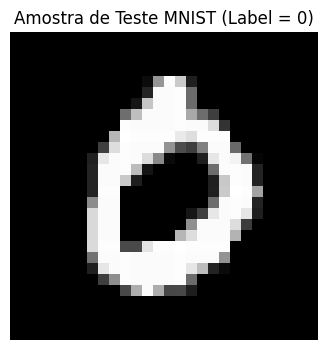

In [14]:
# Visualizar amostra carregada
plt.figure(figsize=(4, 4))
plt.imshow(pixels, cmap="gray")
plt.title(f"Amostra de Teste MNIST (Label = {label})")
plt.axis("off")
plt.show()

In [15]:
# Pré-processar e quantizar imagem (simula processo no Pico)

# 1. Normalizar [0-255] -> [0.0-1.0] (mesmo do treino)
x = pixels.astype(np.float32) / 255.0
x = np.expand_dims(x, axis=(0, 3))  # Shape: [1, 28, 28, 1]

# 2. Quantizar para INT8 usando parâmetros do modelo
in_scale, in_zp = input_details[0]["quantization"]
x_q = np.round(x / in_scale + in_zp).astype(np.int8)

print(f"\nPré-processamento:")
print(f"  Float range: [{x.min():.4f}, {x.max():.4f}]")
print(f"  INT8 range: [{x_q.min()}, {x_q.max()}]")
print(f"  Quantization: scale={in_scale:.6f}, zero_point={in_zp}")


Pré-processamento:
  Float range: [0.0000, 1.0000]
  INT8 range: [-128, 127]
  Quantization: scale=0.003922, zero_point=-128


In [16]:
# Executar inferência
interpreter.set_tensor(input_details[0]["index"], x_q)
interpreter.invoke()

# Obter resultado (10 logits quantizados)
out = interpreter.get_tensor(output_details[0]["index"])[0]
pred = np.argmax(out)

# Dequantizar saída para probabilidades
out_scale, out_zp = output_details[0]["quantization"]
out_float = (out.astype(np.float32) - out_zp) * out_scale

print(f"\nResultado da Inferência:")
print(f"  Predição INT8: {pred}")
print(f"  Label verdadeiro: {label}")
print(f"  {'✓ CORRETO!' if pred == label else '✗ INCORRETO'}")
print(f"\nProbabilidades (softmax aproximado):")
probs = np.exp(out_float) / np.sum(np.exp(out_float))
for i, p in enumerate(probs):
    marker = " ← PREDITO" if i == pred else ""
    print(f"  Dígito {i}: {p*100:5.2f}%{marker}")


Resultado da Inferência:
  Predição INT8: 0
  Label verdadeiro: 0
  ✓ CORRETO!

Probabilidades (softmax aproximado):
  Dígito 0: 17.20% ← PREDITO
  Dígito 1:  8.85%
  Dígito 2:  9.72%
  Dígito 3:  8.85%
  Dígito 4:  9.10%
  Dígito 5:  8.89%
  Dígito 6: 10.59%
  Dígito 7:  8.85%
  Dígito 8:  9.10%
  Dígito 9:  8.85%
